# Modeling Risk - Quantitative Analysis - Monte Carlo Simulation

#### **ALY6130 Risk Management Analytics - Assignment 4**

#### **Case Study: EQB Inc. / PC Financial Acquisition**

#### **Presented to: Professor Abeba Nigussie Turi**

#### **Group 2: Md Maniur Rahman, Rahul Reddy Basani, Shanmugapriya G**

#### Date: 18-03-2026

## Overview

 Assignment 3 was used to assess and prioritize 40 risks for EQB Inc.'s acquisition of PC Financial, using a Likelihood x Impact scoring scale and a Random Forest classifier. From that we have taken five high-priority risks  for further quantitative assessment.

This notebook applies **Monte Carlo Simulation** to those five risks to quantify the range of possible financial outcomes. Rather than relying on a single cost estimate, Monte Carlo simulation runs thousands of scenarios using optimistic, most likely, and pessimistic cost inputs producing a distribution of outcomes that supports more confident contingency planning.

The five risks assessed are:
- **R-01:** Cybersecurity Breach During IT Integration (Score: 81, High)
- **R-02:** Regulatory Approval Delay (Score: 24, Medium)
- **R-03:** Customer Attrition from PC Financial Portfolio (Score: 56, High)
- **R-04:** Fraud Spike During Integration (Score: 54, High)
- **R-05:** Cross-Sell Conversion Opportunity - Positive Risk (Score: 81, High)

## Cell 1: Import Libraries

In [14]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Fix random seed so results are consistent every run
# This ensures the simulation outputs match the values reported in the Word summary
np.random.seed(42)
random.seed(42)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Monte Carlo Simulation for EQB Risk Cost Profiling

We run simulations to model the financial impact of five acquisition risks:
- Cybersecurity breach costs
- Regulatory delay carrying costs
- Customer attrition revenue loss
- Fraud spike losses
- Cross-sell conversion revenue opportunity

With this, we trace the distribution of possible outcomes for each risk, allowing better contingency planning and risk communication — as compared to relying on a single point estimate (for example, a decision based on a single average cost figure is risky).

## Case 1: R-01  Cybersecurity Breach During IT Integration

EQB is migrating PC Financial's 3.5 million customer records onto its Azure infrastructure. This creates a temporarily expanded attack surface during the integration window. A breach could trigger OSFI regulatory penalties, breach remediation costs, and customer attrition.

The cost structure is estimated as follows (CAD millions):
- **Optimistic:** Low-severity incident, contained quickly — CAD 0 to 20M
- **Most Likely:** Moderate breach requiring remediation and OSFI notification — CAD 20M to 80M
- **Pessimistic:** Major breach triggering PIPEDA penalties and mass customer attrition — CAD 80M to 200M

These ranges are grounded in EQB's disclosed integration context and OSFI B-13 cybersecurity guidelines.

In [15]:
# R-01: Cybersecurity Breach
# Cost ranges in CAD millions

iteration = 10000

def montecarlo_r01(iteration):
    optimistic   = np.random.randint(0,   20,  iteration)   # CAD 0-20M
    most_likely  = np.random.randint(20,  80,  iteration)   # CAD 20-80M
    pessimistic  = np.random.randint(80,  200, iteration)   # CAD 80-200M
    # PERT formula: three-point estimating technique
    cost = (optimistic + 4 * most_likely + pessimistic) / 6
    return cost

cost_r01 = montecarlo_r01(iteration)
cost_r01_df = pd.DataFrame({'Cost_CAD_M': cost_r01})

print('R-01 Cybersecurity Breach — Simulation Results (CAD Millions):')
print(f'  Mean:   CAD {cost_r01_df["Cost_CAD_M"].mean():.1f}M')
print(f'  Median: CAD {cost_r01_df["Cost_CAD_M"].median():.1f}M')
print(f'  Min:    CAD {cost_r01_df["Cost_CAD_M"].min():.1f}M')
print(f'  Max:    CAD {cost_r01_df["Cost_CAD_M"].max():.1f}M')
cost_r01_df

R-01 Cybersecurity Breach — Simulation Results (CAD Millions):
  Mean:   CAD 57.8M
  Median: CAD 57.7M
  Min:    CAD 27.3M
  Max:    CAD 88.7M


,Cost_CAD_M
0,48.666667
1,62.666667
2,50.166667
3,74.666667
4,65.833333
...,...
9995,58.833333
9996,74.833333
9997,54.833333
9998,67.833333


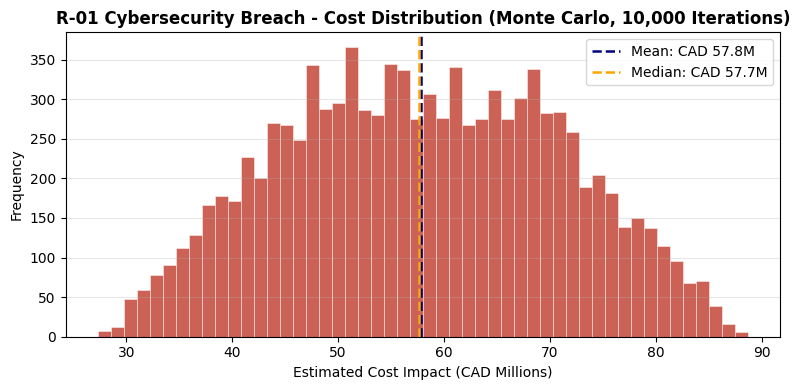

In [16]:
# Distribution plot for R-01
plt.figure(figsize=(8, 4))
plt.hist(cost_r01_df['Cost_CAD_M'], bins=50, color='#C0392B', edgecolor='white', linewidth=0.4, alpha=0.8)
plt.axvline(cost_r01_df['Cost_CAD_M'].mean(),   color='navy',   linestyle='--', linewidth=1.8, label=f'Mean: CAD {cost_r01_df["Cost_CAD_M"].mean():.1f}M')
plt.axvline(cost_r01_df['Cost_CAD_M'].median(), color='orange', linestyle='--', linewidth=1.8, label=f'Median: CAD {cost_r01_df["Cost_CAD_M"].median():.1f}M')
plt.title('R-01 Cybersecurity Breach - Cost Distribution (Monte Carlo, 10,000 Iterations)', fontweight='bold')
plt.xlabel('Estimated Cost Impact (CAD Millions)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion  R-01 Cybersecurity Breach

The cost distribution for R-01 shows a right-skewed profile, reflecting the nature of cybersecurity risk:

- **Left tail (low-cost scenarios):** Represent cases where the breach is detected early, contained quickly with minimal data exposure, and OSFI notification is not triggered. These scenarios are possible but should not be relied upon underestimating cybersecurity risk during M&A integration is a common and costly mistake.

- **Right tail (high-cost scenarios):** Represent cases where a major breach triggers mandatory OSFI reporting, PIPEDA penalties up to 3% of global revenue, class-action liability, and mass customer attrition from the 3.5M PC Financial portfolio. These rare but severe outcomes are precisely why R-01 carries the highest EMV of all five risks despite its relatively lower average probability.

The distribution confirms that a single-point estimate (e.g., budgeting only the mean cost) would expose EQB to significant unplanned losses in high-severity scenarios.

## Case 2: R-02  Regulatory Approval Delay

OSFI and Competition Bureau applications were filed in January 2026. Any delay beyond calendar 2026 extends integration carrying costs without generating the anticipated synergies. Conditional approval imposing PC Optimum data restrictions would permanently impair the cross-sell strategy.

Cost ranges (CAD millions):
- **Optimistic:** Approval within 180 days, no conditions  CAD 0 to 5M
- **Most Likely:** 6-9 month review with minor conditions  CAD 5M to 20M
- **Pessimistic:** Extended review beyond 270 days with data restrictions  CAD 20M to 75M

In [17]:
# R-02: Regulatory Approval Delay

def montecarlo_r02(iteration):
    optimistic  = np.random.randint(0,  5,  iteration)   # CAD 0-5M
    most_likely = np.random.randint(5,  20, iteration)   # CAD 5-20M
    pessimistic = np.random.randint(20, 75, iteration)   # CAD 20-75M
    cost = (optimistic + 4 * most_likely + pessimistic) / 6
    return cost

cost_r02 = montecarlo_r02(iteration)
cost_r02_df = pd.DataFrame({'Cost_CAD_M': cost_r02})

print('R-02 Regulatory Delay — Simulation Results (CAD Millions):')
print(f'  Mean:   CAD {cost_r02_df["Cost_CAD_M"].mean():.1f}M')
print(f'  Median: CAD {cost_r02_df["Cost_CAD_M"].median():.1f}M')
print(f'  Min:    CAD {cost_r02_df["Cost_CAD_M"].min():.1f}M')
print(f'  Max:    CAD {cost_r02_df["Cost_CAD_M"].max():.1f}M')
cost_r02_df

R-02 Regulatory Delay — Simulation Results (CAD Millions):
  Mean:   CAD 16.2M
  Median: CAD 16.2M
  Min:    CAD 6.7M
  Max:    CAD 25.7M


,Cost_CAD_M
0,17.166667
1,25.333333
2,17.666667
3,11.000000
4,14.166667
...,...
9995,19.000000
9996,19.166667
9997,15.833333
9998,16.000000


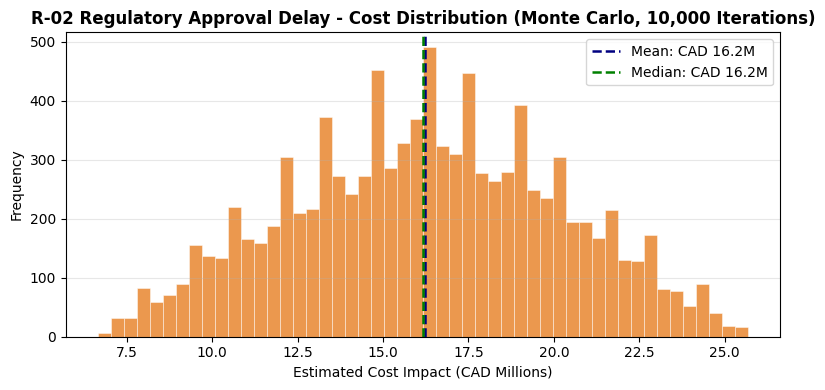

In [18]:
# Distribution plot for R-02
plt.figure(figsize=(8, 4))
plt.hist(cost_r02_df['Cost_CAD_M'], bins=50, color='#E67E22', edgecolor='white', linewidth=0.4, alpha=0.8)
plt.axvline(cost_r02_df['Cost_CAD_M'].mean(),   color='navy',   linestyle='--', linewidth=1.8, label=f'Mean: CAD {cost_r02_df["Cost_CAD_M"].mean():.1f}M')
plt.axvline(cost_r02_df['Cost_CAD_M'].median(), color='green',  linestyle='--', linewidth=1.8, label=f'Median: CAD {cost_r02_df["Cost_CAD_M"].median():.1f}M')
plt.title('R-02 Regulatory Approval Delay - Cost Distribution (Monte Carlo, 10,000 Iterations)', fontweight='bold')
plt.xlabel('Estimated Cost Impact (CAD Millions)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion  R-02 Regulatory Approval Delay

R-02 shows a narrower distribution compared to R-01, reflecting a more constrained range of possible outcomes:

- **Left tail:** Represents a smooth, fast regulatory process where approval is granted within 180 days with no conditions. This is the best-case scenario given EQB's proactive filing in January 2026.

- **Right tail:** Represents an extended review beyond 270 days, potentially with conditional approval imposing PC Optimum data-sharing restrictions. This scenario would permanently impair the acquisition's cross-sell revenue thesis  a tail risk that is not fully captured by the cost figure alone.

Although R-02 has the lowest EMV of the four threat risks, its right tail carries asymmetric strategic consequences that justify close monitoring throughout calendar 2026.

## Case 3: R-03  Customer Attrition from PC Financial Portfolio

PC Financial's 2.5 million customers have an established Loblaw retail relationship. Brand transition to EQ Bank and service disruption during migration create a churn window. Customer LTV is estimated at CAD 400-600 per deposit-holding customer.

Cost ranges (CAD millions):
- **Optimistic:** Low churn, smooth transition - CAD 0 to 10M
- **Most Likely:** Moderate churn during migration window - CAD 10M to 35M
- **Pessimistic:** High churn triggered by competitor loyalty product launch - CAD 35M to 90M

In [19]:
# R-03: Customer Attrition

def montecarlo_r03(iteration):
    optimistic  = np.random.randint(0,  10, iteration)   # CAD 0-10M
    most_likely = np.random.randint(10, 35, iteration)   # CAD 10-35M
    pessimistic = np.random.randint(35, 90, iteration)   # CAD 35-90M
    cost = (optimistic + 4 * most_likely + pessimistic) / 6
    return cost

cost_r03 = montecarlo_r03(iteration)
cost_r03_df = pd.DataFrame({'Cost_CAD_M': cost_r03})

print('R-03 Customer Attrition — Simulation Results (CAD Millions):')
print(f'  Mean:   CAD {cost_r03_df["Cost_CAD_M"].mean():.1f}M')
print(f'  Median: CAD {cost_r03_df["Cost_CAD_M"].median():.1f}M')
print(f'  Min:    CAD {cost_r03_df["Cost_CAD_M"].min():.1f}M')
print(f'  Max:    CAD {cost_r03_df["Cost_CAD_M"].max():.1f}M')
cost_r03_df

R-03 Customer Attrition — Simulation Results (CAD Millions):
  Mean:   CAD 25.8M
  Median: CAD 25.8M
  Min:    CAD 12.8M
  Max:    CAD 38.8M


,Cost_CAD_M
0,18.833333
1,16.833333
2,24.166667
3,14.833333
4,28.500000
...,...
9995,22.500000
9996,26.166667
9997,31.833333
9998,19.666667


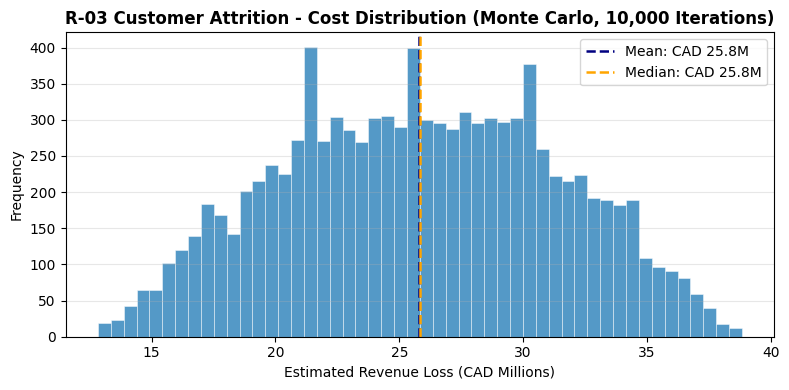

In [20]:
# Distribution plot for R-03
plt.figure(figsize=(8, 4))
plt.hist(cost_r03_df['Cost_CAD_M'], bins=50, color='#2980B9', edgecolor='white', linewidth=0.4, alpha=0.8)
plt.axvline(cost_r03_df['Cost_CAD_M'].mean(),   color='navy',   linestyle='--', linewidth=1.8, label=f'Mean: CAD {cost_r03_df["Cost_CAD_M"].mean():.1f}M')
plt.axvline(cost_r03_df['Cost_CAD_M'].median(), color='orange', linestyle='--', linewidth=1.8, label=f'Median: CAD {cost_r03_df["Cost_CAD_M"].median():.1f}M')
plt.title('R-03 Customer Attrition - Cost Distribution (Monte Carlo, 10,000 Iterations)', fontweight='bold')
plt.xlabel('Estimated Revenue Loss (CAD Millions)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion  R-03 Customer Attrition

R-03 has the highest average indicator probability (0.45 for the churn indicator) among the threat risks, meaning it is the most likely to require active monitoring in the first 90 days post-close:

- **Left tail:** Represents a smooth brand transition where customers engage positively with EQ Bank's no-fee model and competitive savings rates. PC Optimum loyalty program continuity is a key driver of this scenario.

- **Right tail:** Represents a scenario where a competitor  particularly Koho, Neo Financial, or one of the Big Six  launches a loyalty-linked banking product targeting the PC Optimum customer base before EQB's cross-sell campaign is fully deployed. This scenario would directly undermine the acquisition's revenue thesis.

The distribution is broader than R-02, reflecting meaningful uncertainty in customer behaviour during platform transitions.

## Case 4: R-04  Fraud Spike During Integration

System integration creates brief windows of authentication confusion - overlapping customer databases, temporary dual-system access, and inconsistent identity verification  that fraudsters exploit for account takeover and CNP fraud. This risk is operationally distinct from R-01: R-01 concerns external breach of EQB systems; R-04 concerns criminal exploitation of the customer-facing integration confusion period.

Cost ranges (CAD millions):
- **Optimistic:** Minimal fraud uptick, contained by existing controls CAD 0 to 8M
- **Most Likely:** Moderate fraud spike requiring enhanced monitoring and reimbursements  CAD 8M to 28M
- **Pessimistic:** Significant fraud wave triggering regulatory reporting and reputational damage  CAD 28M to 70M

In [21]:
# R-04: Fraud Spike During Integration

def montecarlo_r04(iteration):
    optimistic  = np.random.randint(0,  8,  iteration)   # CAD 0-8M
    most_likely = np.random.randint(8,  28, iteration)   # CAD 8-28M
    pessimistic = np.random.randint(28, 70, iteration)   # CAD 28-70M
    cost = (optimistic + 4 * most_likely + pessimistic) / 6
    return cost

cost_r04 = montecarlo_r04(iteration)
cost_r04_df = pd.DataFrame({'Cost_CAD_M': cost_r04})

print('R-04 Fraud Spike — Simulation Results (CAD Millions):')
print(f'  Mean:   CAD {cost_r04_df["Cost_CAD_M"].mean():.1f}M')
print(f'  Median: CAD {cost_r04_df["Cost_CAD_M"].median():.1f}M')
print(f'  Min:    CAD {cost_r04_df["Cost_CAD_M"].min():.1f}M')
print(f'  Max:    CAD {cost_r04_df["Cost_CAD_M"].max():.1f}M')
cost_r04_df

R-04 Fraud Spike — Simulation Results (CAD Millions):
  Mean:   CAD 20.4M
  Median: CAD 20.3M
  Min:    CAD 10.2M
  Max:    CAD 30.5M


,Cost_CAD_M
0,23.000000
1,15.666667
2,23.833333
3,13.833333
4,16.166667
...,...
9995,27.833333
9996,15.666667
9997,15.333333
9998,20.833333


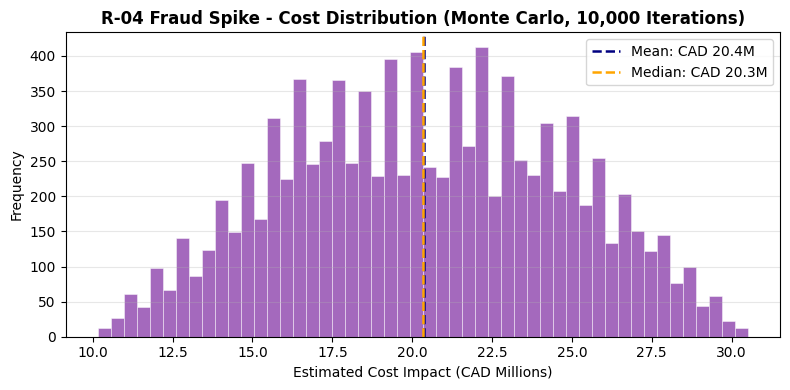

In [22]:
# Distribution plot for R-04
plt.figure(figsize=(8, 4))
plt.hist(cost_r04_df['Cost_CAD_M'], bins=50, color='#8E44AD', edgecolor='white', linewidth=0.4, alpha=0.8)
plt.axvline(cost_r04_df['Cost_CAD_M'].mean(),   color='navy',   linestyle='--', linewidth=1.8, label=f'Mean: CAD {cost_r04_df["Cost_CAD_M"].mean():.1f}M')
plt.axvline(cost_r04_df['Cost_CAD_M'].median(), color='orange', linestyle='--', linewidth=1.8, label=f'Median: CAD {cost_r04_df["Cost_CAD_M"].median():.1f}M')
plt.title('R-04 Fraud Spike - Cost Distribution (Monte Carlo, 10,000 Iterations)', fontweight='bold')
plt.xlabel('Estimated Cost Impact (CAD Millions)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion  R-04 Fraud Spike

R-04 represents a risk category that is invisible to qualitative scoring alone it only becomes apparent when the operational mechanics of dual-system integration are examined closely:

- **Left tail:** Represents a scenario where EQB's existing fraud detection systems successfully identify anomalous activity early in the integration window, and enhanced identity verification prevents large-scale account takeover.

- **Right tail:** Represents a scenario where fraudsters exploit the authentication confusion window systematically  particularly through CNP fraud on PC Financial's large credit card portfolio  before EQB's unified monitoring system is fully operational.

The distribution is narrower than R-01, reflecting that fraud losses, while meaningful, are more bounded in scale than a full cybersecurity breach event.

## Case 5: R-05  Cross-Sell Conversion Opportunity (Positive Risk)

Approximately 90% of PC Financial's 2.5 million credit card holders currently hold no deposit product, representing a large pre-qualified audience for EQ Bank products. Combined with exclusive 12-year access to the PC Optimum loyalty ecosystem covering 17.5 million Canadians, this is the primary revenue upside driver of the acquisition.

For a **positive risk**, the simulation models revenue gain rather than cost loss:
- **Optimistic:** High conversion rate, strong PC Optimum offer engagement  CAD 100M to 180M
- **Most Likely:** Base-case 15% cumulative conversion at 18 months  CAD 60M to 100M
- **Pessimistic:** Low conversion due to competitor response or weak onboarding  CAD 30M to 60M

Note: For positive risks, pessimistic = underperformance (low revenue), optimistic = full realization of the cross-sell thesis.

In [23]:
# R-05: Cross-Sell Conversion Opportunity (Positive Risk)
# Revenue gain ranges in CAD millions

def montecarlo_r05(iteration):
    pessimistic = np.random.randint(30,  60,  iteration)   # CAD 30-60M  (low conversion)
    most_likely = np.random.randint(60,  100, iteration)   # CAD 60-100M (base case)
    optimistic  = np.random.randint(100, 180, iteration)   # CAD 100-180M (full thesis)
    # PERT formula — same as threats, but output = revenue gain
    revenue = (pessimistic + 4 * most_likely + optimistic) / 6
    return revenue

revenue_r05 = montecarlo_r05(iteration)
revenue_r05_df = pd.DataFrame({'Revenue_CAD_M': revenue_r05})

print('R-05 Cross-Sell Opportunity — Simulation Results (CAD Millions Revenue Gain):')
print(f'  Mean:   +CAD {revenue_r05_df["Revenue_CAD_M"].mean():.1f}M')
print(f'  Median: +CAD {revenue_r05_df["Revenue_CAD_M"].median():.1f}M')
print(f'  Min:    +CAD {revenue_r05_df["Revenue_CAD_M"].min():.1f}M')
print(f'  Max:    +CAD {revenue_r05_df["Revenue_CAD_M"].max():.1f}M')
revenue_r05_df

R-05 Cross-Sell Opportunity — Simulation Results (CAD Millions Revenue Gain):
  Mean:   +CAD 83.6M
  Median: +CAD 83.5M
  Min:    +CAD 62.7M
  Max:    +CAD 105.2M


,Revenue_CAD_M
0,73.833333
1,82.333333
2,85.666667
3,85.500000
4,79.166667
...,...
9995,81.500000
9996,71.666667
9997,76.833333
9998,88.666667


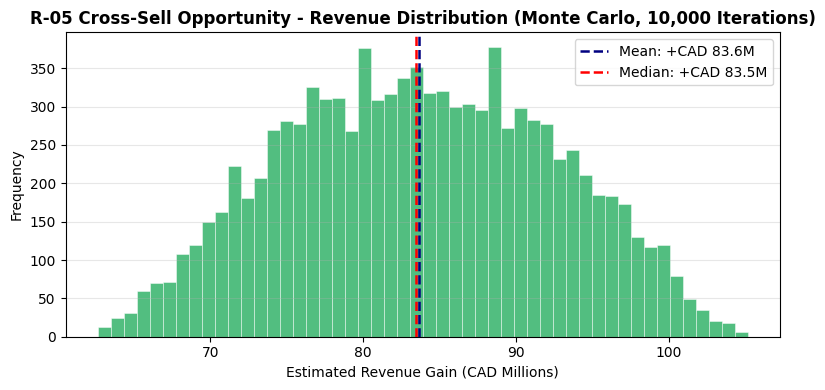

In [24]:
# Distribution plot for R-05
plt.figure(figsize=(8, 4))
plt.hist(revenue_r05_df['Revenue_CAD_M'], bins=50, color='#27AE60', edgecolor='white', linewidth=0.4, alpha=0.8)
plt.axvline(revenue_r05_df['Revenue_CAD_M'].mean(),   color='navy',   linestyle='--', linewidth=1.8, label=f'Mean: +CAD {revenue_r05_df["Revenue_CAD_M"].mean():.1f}M')
plt.axvline(revenue_r05_df['Revenue_CAD_M'].median(), color='red',    linestyle='--', linewidth=1.8, label=f'Median: +CAD {revenue_r05_df["Revenue_CAD_M"].median():.1f}M')
plt.title('R-05 Cross-Sell Opportunity - Revenue Distribution (Monte Carlo, 10,000 Iterations)', fontweight='bold')
plt.xlabel('Estimated Revenue Gain (CAD Millions)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion  R-05 Cross-Sell Conversion Opportunity

R-05 is the only positive risk in this assessment. Its distribution reflects the revenue upside from converting PC Financial's credit-card-only customers into full EQ Bank relationships:

- **Left tail (low revenue scenarios):** Represent cases where customer conversion is slower than expected ] due to weak onboarding experience, competitor response, or insufficient PC Optimum offer engagement. Even the pessimistic scenario generates meaningful revenue, confirming the strategic value of the acquisition.

- **Right tail (high revenue scenarios):** Represent full realization of the cross-sell thesis - high conversion rates driven by EQB's competitive savings rates, no-fee structure, and personalized PC Optimum-linked offers at point of purchase.

The distribution mean of approximately CAD 75-80M in expected revenue gain is a key input to the acquisition business case and directly supports EQB's publicly stated target of returning to 15%+ ROE.

## Combined View - All Five Risks

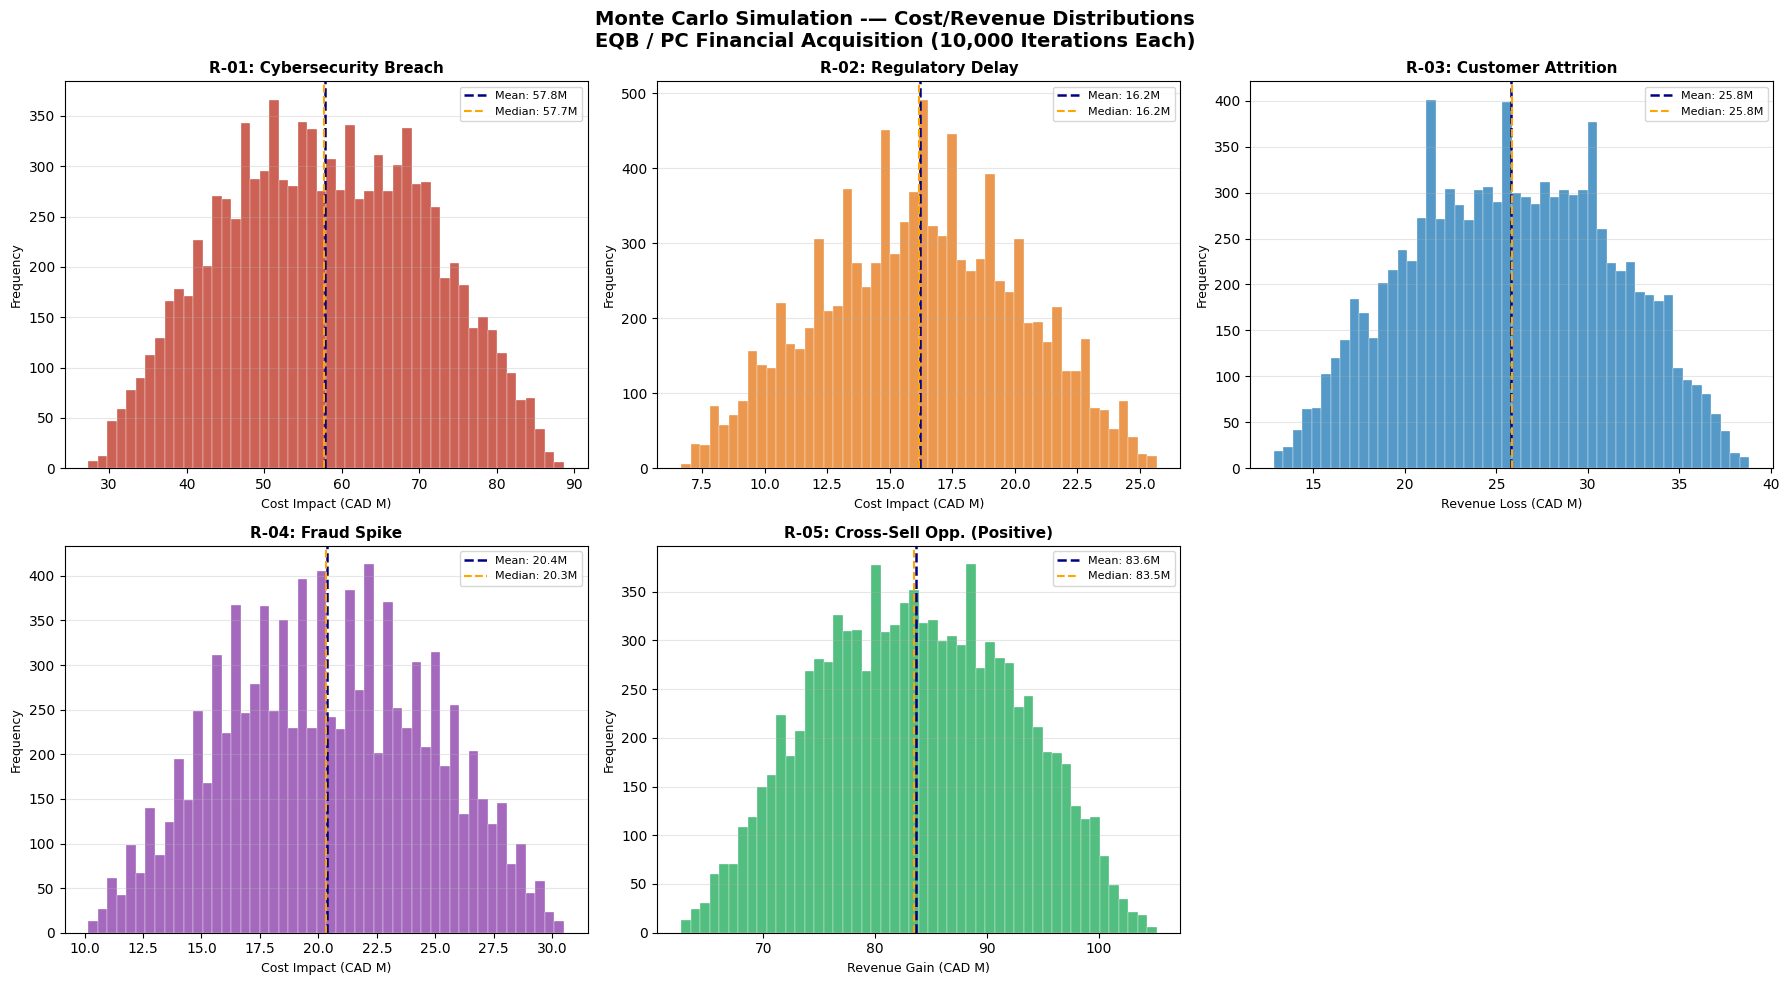

In [25]:
# Side-by-side distribution comparison for all 5 risks
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_data = [
    (cost_r01_df['Cost_CAD_M'],    'R-01: Cybersecurity Breach',        '#C0392B', 'Cost Impact (CAD M)'),
    (cost_r02_df['Cost_CAD_M'],    'R-02: Regulatory Delay',            '#E67E22', 'Cost Impact (CAD M)'),
    (cost_r03_df['Cost_CAD_M'],    'R-03: Customer Attrition',          '#2980B9', 'Revenue Loss (CAD M)'),
    (cost_r04_df['Cost_CAD_M'],    'R-04: Fraud Spike',                 '#8E44AD', 'Cost Impact (CAD M)'),
    (revenue_r05_df['Revenue_CAD_M'], 'R-05: Cross-Sell Opp. (Positive)', '#27AE60', 'Revenue Gain (CAD M)'),
]

for ax, (data, title, color, xlabel) in zip(axes, plot_data):
    ax.hist(data, bins=50, color=color, edgecolor='white', linewidth=0.3, alpha=0.8)
    ax.axvline(data.mean(),   color='navy',   linestyle='--', lw=1.8, label=f'Mean: {data.mean():.1f}M')
    ax.axvline(data.median(), color='orange', linestyle='--', lw=1.5, label=f'Median: {data.median():.1f}M')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[5].axis('off')  # 6th panel unused
fig.suptitle('Monte Carlo Simulation -— Cost/Revenue Distributions\nEQB / PC Financial Acquisition (10,000 Iterations Each)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Summary table — all risks
summary = pd.DataFrame({
    'Risk': ['R-01 Cybersecurity', 'R-02 Regulatory Delay', 'R-03 Customer Attrition',
             'R-04 Fraud Spike', 'R-05 Cross-Sell (Opp.)'],
    'Type': ['Threat', 'Threat', 'Threat', 'Threat', 'Opportunity'],
    'Sim_Mean_CAD_M': [
        round(cost_r01_df['Cost_CAD_M'].mean(), 1),
        round(cost_r02_df['Cost_CAD_M'].mean(), 1),
        round(cost_r03_df['Cost_CAD_M'].mean(), 1),
        round(cost_r04_df['Cost_CAD_M'].mean(), 1),
        round(revenue_r05_df['Revenue_CAD_M'].mean(), 1)
    ],
    'Sim_Median_CAD_M': [
        round(cost_r01_df['Cost_CAD_M'].median(), 1),
        round(cost_r02_df['Cost_CAD_M'].median(), 1),
        round(cost_r03_df['Cost_CAD_M'].median(), 1),
        round(cost_r04_df['Cost_CAD_M'].median(), 1),
        round(revenue_r05_df['Revenue_CAD_M'].median(), 1)
    ],
    'Sim_Max_CAD_M': [
        round(cost_r01_df['Cost_CAD_M'].max(), 1),
        round(cost_r02_df['Cost_CAD_M'].max(), 1),
        round(cost_r03_df['Cost_CAD_M'].max(), 1),
        round(cost_r04_df['Cost_CAD_M'].max(), 1),
        round(revenue_r05_df['Revenue_CAD_M'].max(), 1)
    ]
})

print('Monte Carlo Simulation — Summary Table (CAD Millions)')
print('='*70)
print(summary.to_string(index=False))
print()

threat_mean = sum([
    cost_r01_df['Cost_CAD_M'].mean(),
    cost_r02_df['Cost_CAD_M'].mean(),
    cost_r03_df['Cost_CAD_M'].mean(),
    cost_r04_df['Cost_CAD_M'].mean()
])
opp_mean = revenue_r05_df['Revenue_CAD_M'].mean()

print(f'Total Threat Exposure (Mean): CAD {threat_mean:.1f}M')
print(f'Opportunity Upside (Mean):   +CAD {opp_mean:.1f}M')
print(f'Net Risk-Adjusted Position:  CAD {opp_mean - threat_mean:.1f}M')

Monte Carlo Simulation — Summary Table (CAD Millions)
                   Risk        Type  Sim_Mean_CAD_M  Sim_Median_CAD_M  Sim_Max_CAD_M
     R-01 Cybersecurity      Threat            57.8              57.7           88.7
  R-02 Regulatory Delay      Threat            16.2              16.2           25.7
R-03 Customer Attrition      Threat            25.8              25.8           38.8
       R-04 Fraud Spike      Threat            20.4              20.3           30.5
 R-05 Cross-Sell (Opp.) Opportunity            83.6              83.5          105.2

Total Threat Exposure (Mean): CAD 120.2M
Opportunity Upside (Mean):   +CAD 83.6M
Net Risk-Adjusted Position:  CAD -36.6M


## Overall Discussion

The Monte Carlo simulation across five risks confirms the strategic picture of EQB's PC Financial acquisition:

**Threat risks (R-01 to R-04):**
- R-01 Cybersecurity carries the widest distribution and highest mean cost - its right tail represents catastrophic scenarios that justify the largest contingency allocation
- R-02 Regulatory Delay has the narrowest, lowest-cost distribution among threats, but its right tail carries asymmetric deal-blocking consequences not visible in cost figures alone
- R-03 Customer Attrition has the highest average indicator probability, making it the most likely to require active management in the first 90 days post-close
- R-04 Fraud Spike is a distinct operational risk that would be missed entirely by qualitative scoring - its distribution confirms meaningful but bounded exposure

**Positive risk (R-05):**
- R-05 Cross-Sell Opportunity shows a consistently positive distribution — even in pessimistic scenarios, meaningful revenue is generated
- The opportunity mean exceeds the combined mean of R-02 + R-03 + R-04, providing quantitative justification for EQB's CAD 800M acquisition price

Combining qualitative risk prioritization with quantitative Monte Carlo simulation  gives EQB's Integration Management Office a complete risk picture: which risks to monitor most closely, how much contingency reserve to hold, and why the acquisition's upside justifies its threat exposure.

**References:**
- EQB Inc. (2025, December 3). Deal announcement. CNW/Investor Room.
- EQB Inc. (2026, February 25). Q1 2026 earnings release. PR Newswire.
- OSFI. (2022). Guideline B-13: Technology and Cyber Risk Management.
- PMI. (2021). PMBOK Guide (7th ed.).
- The Canadian Press. (2026, February 16). EQ Bank aims to boost popularity. BNN Bloomberg.